## Huang et al., 

In [2]:
def calc_asp(M, nu):
    """
    Calculate the aspect ratio using scaling relations (EQ 2 & 3)
    from Huang et al. (2024), given the magnitude, M, and an
    array of dips (in degrees), nu.
    """
    c0 = 0.1139
    c1 = 0.532
    c2 = 7.17
    c3 = -0.0105

    M_BP = c2 + c3 * nu

    aspect = 10 ** (c0 + c1 * (M - M_BP))
    aspect[M <= M_BP] = 10**c0
    return aspect

In [3]:
import numpy as np
import math
aspect = calc_asp(8.8, np.array([18.0, 18.0]))
aspect

array([12.06724138, 12.06724138])

## Thingbaijam et al., 2017

In [2]:
def calc_thingbaijam(M):
    """
    Calculate the width 
    """
    # Calc legnth
    b = 0.583
    a = -2.412
    length = 10 ** (a + b*M)

    # Calc width
    b = 0.366
    a = -0.880
    width = 10 ** (a + b*M)

    # Calc area
    b = 0.949
    a = -3.292
    area = 10 ** (a + b*M)

    return length, width, area



In [4]:
length, width, area = calc_thingbaijam(8.93)
print(f"Length: {int(length)}km, Width: {int(width)}km, Area: {int(area)}km^2")
print(f"Aspect Ratio: {length/width}")

Length: 622km, Width: 244km, Area: 152254km^2
Aspect Ratio: 2.5457162805382154


## Strasser et al. 2010
Subduction Intraslab and Interface

In [3]:
%run -i '/Users/hyin/soft/esi-shakelib/src/esi_shakelib/ffsimmer.py'

In [4]:

# Strasser Interface
(length_mean,_, width_mean, _,area_mean, area_std,) = dimensions_from_magnitude(7.0, MagScaling.SEA10_INTERFACE, 1, 0, Mechanism.ALL)
print(f"Length (km): {length_mean}, Width (km): {width_mean}")
print(f"Area (km^2): {area_mean} +/-  {area_std}")

# Strasser Intraslab
(length_mean,_, width_mean, _,area_mean, area_std,) = dimensions_from_magnitude(7.0, MagScaling.SEA10_SLAB, 1, 0, Mechanism.ALL)
print(f"Length (km): {length_mean}, Width (km): {width_mean}")
print(f"Area (km^2): {area_mean} +/-  {area_std}")

# Thingbaijam shallow crustal subduction 
(length_mean,_, width_mean, _,area_mean, area_std,) = dimensions_from_magnitude(7.0, MagScaling.TEA17, 1, 0, Mechanism.NM)
print(f"Length (km): {length_mean}, Width (km): {width_mean}")
print(f"Area (km^2): {area_mean} +/-  {area_std}")

# W&C 1994 default for "all" mechanism
(length_mean,_, width_mean, _,area_mean, area_std,) = dimensions_from_magnitude(7.0, MagScaling.WC94, 1, 0, Mechanism.ALL)
print(f"Length (km): {length_mean}, Width (km): {width_mean}")
print(f"Area (km^2): {area_mean} +/-  {area_std}")


Length (km): [41.49540426], Width (km): [37.58374043]
Area (km^2): [1492.79440958] +/-  0.304
Length (km): [38.37072455], Width (km): [27.16439269]
Area (km^2): [1011.57945426] +/-  0.184
Length (km): [47.09773264], Width (km): [27.03958364]
Area (km^2): [1273.50308102] +/-  0.181
Length (km): [48.97788194], Width (km): [16.98243652]
Area (km^2): [758.57757503] +/-  0.24


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
mags = np.linspace(5.5, 9.0, 100)

def get_dimension_curves(mscale, mech):
    L_mean, L_std = [], []
    W_mean, W_std = [], []
    A_mean, A_std = [], []
    
    for M in mags:
        (length_mean, length_std,
         width_mean, width_std,
         area_mean, area_std) = dimensions_from_magnitude(
            M, mscale, 1, 0, mech
        )

        # Convert to scalars to avoid (100,1) issue
        L_mean.append(float(length_mean))
        L_std.append(float(length_std))
        W_mean.append(float(width_mean))
        W_std.append(float(width_std))
        A_mean.append(float(area_mean))
        A_std.append(float(area_std))
        
    return (
        np.array(L_mean), np.array(L_std),
        np.array(W_mean), np.array(W_std),
        np.array(A_mean), np.array(A_std),
    )

# SEA10 Interface
(L_sea10_int, Lstd_sea10_int,
 W_sea10_int, Wstd_sea10_int,
 A_sea10_int, Astd_sea10_int) = get_dimension_curves(
    MagScaling.SEA10_INTERFACE, Mechanism.ALL
)

# SEA10 Slab
(L_sea10_slab, Lstd_sea10_slab,
 W_sea10_slab, Wstd_sea10_slab,
 A_sea10_slab, Astd_sea10_slab) = get_dimension_curves(
    MagScaling.SEA10_SLAB, Mechanism.ALL
)

# TEA17 Non-interface
(L_tea17, Lstd_tea17,
 W_tea17, Wstd_tea17,
 A_tea17, Astd_tea17) = get_dimension_curves(
    MagScaling.TEA17, Mechanism.RS
)

# TEA17 interface
(L_tea17_int, Lstd_tea17_int,
 W_tea17_int, Wstd_tea17_int,
 A_tea17_int, Astd_tea17_int) = get_dimension_curves(
    MagScaling.TEA17_INTERFACE, Mechanism.ALL
)

# WC94
(L_wc94, Lstd_wc94,
 W_wc94, Wstd_wc94,
 A_wc94, Astd_wc94) = get_dimension_curves(
    MagScaling.WC94, Mechanism.ALL
)



/var/folders/m7/l57r7sp51gs_ymb363731m18hycmz0/T/ipykernel_37044/21305508.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L_mean.append(float(length_mean))
/var/folders/m7/l57r7sp51gs_ymb363731m18hycmz0/T/ipykernel_37044/21305508.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W_mean.append(float(width_mean))
/var/folders/m7/l57r7sp51gs_ymb363731m18hycmz0/T/ipykernel_37044/21305508.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A_mean.append(float(a

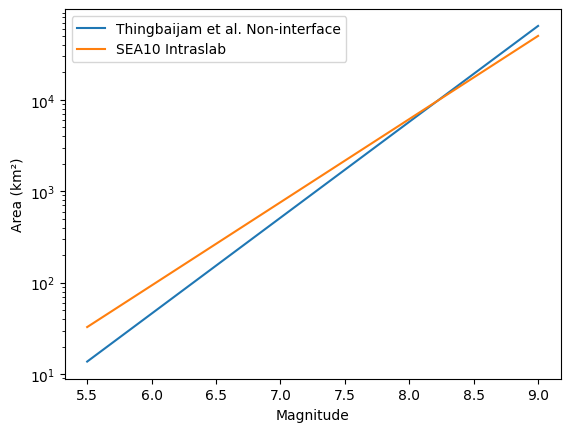

In [22]:
# Plot
plt.figure()

def plot_with_uncertainty(x, mean, std, label):
    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plot_with_uncertainty(mags,  A_tea17, Astd_tea17, "Thingbaijam et al. Non-interface")
# plot_with_uncertainty(mags, A_sea10_slab, Astd_sea10_int, "SEA10 Interface")
plot_with_uncertainty(mags, A_wc94, Astd_wc94, "SEA10 Intraslab")

plt.yscale("log")
plt.xlabel("Magnitude")
plt.ylabel("Area (km²)")
plt.legend()
plt.savefig("/Users/hyin/usgs_mendenhall/ffsimmer/catalog/scaling-relationships/mag-area-intraslab.png")

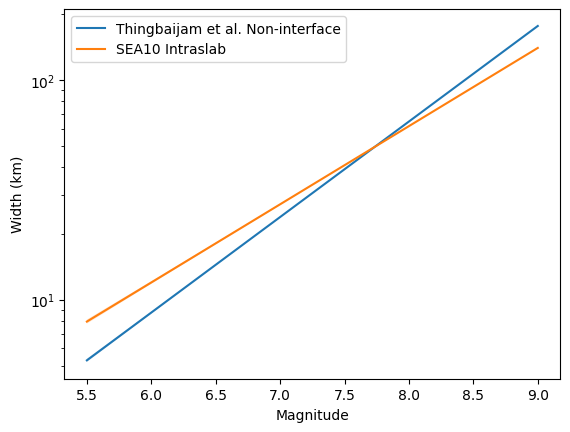

In [ ]:
# Plot
plt.figure()

plot_with_uncertainty(mags,  W_tea17, Wstd_tea17, "Thingbaijam et al. Non-interface")
plot_with_uncertainty(mags, W_sea10_slab, Wstd_sea10_int, "SEA10 Intraslab")

plt.yscale("log")
plt.xlabel("Magnitude")
plt.ylabel("Width (km)")
plt.legend()
plt.savefig("/Users/hyin/usgs_mendenhall/ffsimmer/catalog/scaling-relationships/mag-width-intraslab.png")


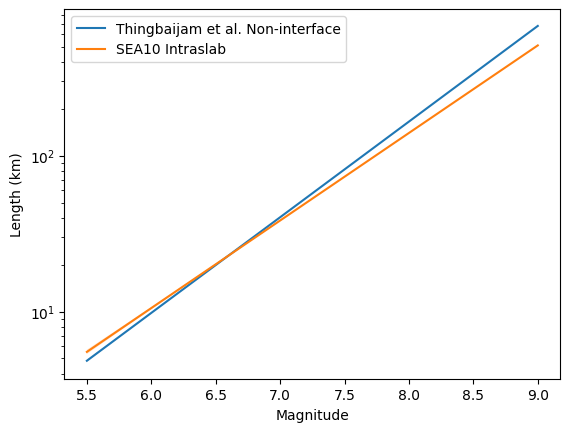

In [20]:
# Plot
plt.figure()

plot_with_uncertainty(mags,  L_tea17, Lstd_tea17, "Thingbaijam et al. Non-interface")
plot_with_uncertainty(mags, L_sea10_slab, Lstd_sea10_int, "SEA10 Intraslab")
# plot_with_uncertainty(mags, L_wc94, Lstd_wc94, "SEA10 Interface")

plt.yscale("log")
plt.xlabel("Magnitude")
plt.ylabel("Length (km)")
plt.legend()
plt.savefig("/Users/hyin/usgs_mendenhall/ffsimmer/catalog/scaling-relationships/mag-length-intraslab.png")


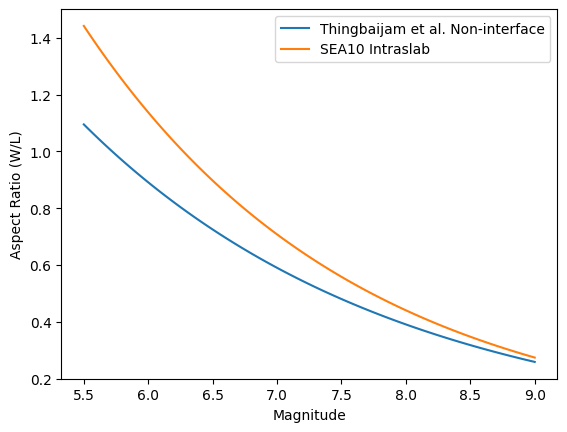

In [21]:
plt.figure()

asp_sea10_slab = W_sea10_slab/L_sea10_slab
asp_tea17 = W_tea17/L_tea17
asp_wc94 = W_wc94/L_wc94

plt.plot(mags,  asp_tea17, label="Thingbaijam et al. Non-interface")
plt.plot(mags, asp_sea10_slab, label="SEA10 Intraslab")
# plt.plot(mags, asp_wc94, label="W&C 1994")
plt.xlabel("Magnitude")
plt.ylabel("Aspect Ratio (W/L)")
plt.legend()
plt.savefig("/Users/hyin/usgs_mendenhall/ffsimmer/catalog/scaling-relationships/mag-aspect-intraslab.png")